# Векторный поиск и RAG: построение индекса Qdrant и анализ производительности HNSW

**Автор:** Дмитрий Азарпов  
**Дата:** 28.05.2026  
**Описание:** Исследование влияния параметров индекса HNSW в Qdrant на скорость и качество поиска с использованием русскоязычных данных из SQLite и модели SentenceTransformer.


## Оглавление

0. [Введение](#введение)
1. [Настройка окружения](#1-настройка-окружения)
   - 1.1 [Установка зависимостей](#11-установка-зависимостей)
   - 1.2 [Импорт библиотек](#12-импорт-библиотек)
2. [Загрузка данных из SQLite](#2-загрузка-данных-из-sqlite)
   - 2.1 [Подключение к базе данных](#21-подключение-к-базе-данных)
   - 2.2 [Извлечение и первичный анализ](#22-извлечение-и-первичный-анализ)
   - 2.3 [Предобработка: очистка текстов](#23-предобработка-очистка-текстов)
3. [Создание поисковых представлений и векторизация](#3-создание-поисковых-представлений-и-векторизация)
   - 3.1 [Создание display_texts и search_texts](#31-создание-display_texts-и-search_texts)
   - 3.2 [Dense-векторизация: модель multilingual-e5-large](#32-dense-векторизация-модель-multilingual-e5-large)
   - 3.3 [Sparse-векторизация: TF-IDF](#33-sparse-векторизация-tf-idf)
4. [Построение векторной базы Qdrant](#4-построение-векторной-базы-qdrant)
5. [Гибридный поиск (dense + sparse) с RRF](#5-гибридный-поиск-dense--sparse-с-rrf)
6. [Бенчмаркинг индекса HNSW](#6-бенчмаркинг-индекса-hnsw)
   - 6.1 [Подготовка запросов и эталонного поиска](#61-подготовка-запросов-и-эталонного-поиска)
   - 6.2 [Класс результатов и функция бенчмарка](#62-класс-результатов-и-функция-бенчмарка)
   - 6.3 [Анализ recall при разных K](#63-анализ-recall-при-разных-k)
   - 6.4 [Влияние параметра m](#64-влияние-параметра-m-графа-hnsw)
   - 6.5 [Влияние параметра ef поиска](#65-влияние-параметра-ef-поиска)
7. [Визуализация и анализ](#7-визуализация-и-анализ)
8. [Ключевые выводы](#8-ключевые-выводы)


<a id="введение"></a>
## Введение

**Векторный поиск** — ключевой компонент современных RAG-систем (Retrieval-Augmented Generation). В отличие от классического полнотекстового поиска, он позволяет находить семантически близкие документы, даже если они не содержат одинаковых ключевых слов.

**Qdrant** — высокопроизводительная векторная СУБД с открытым исходным кодом, поддерживающая фильтрацию метаданных и различные алгоритмы приближённого поиска ближайших соседей (ANN). Внутри Qdrant по умолчанию используется графовый индекс **HNSW** (Hierarchical Navigable Small World), который обеспечивает логарифмическую сложность поиска при высокой полноте (recall).

### Что такое HNSW?

**HNSW** — Hierarchical Navigable Small World — это алгоритм приближённого поиска ближайших соседей (ANN — Approximate Nearest Neighbors), используемый в Qdrant и FAISS по умолчанию.

Из 10 000 документов каждый — точка в 1024-мерном пространстве. Brute-force перебирает **все 10 000**. HNSW перебирает **~100** — в 100 раз быстрее, жертвуя долей процента точности.

Алгоритм строит **многослойный граф**, который перемещаясь сначала по трассе или по КАДУ, сворачивает на более маленькие улицы):

```
Слой 2 (верхний):  ●────●      <-- "хайвеи" — быстрые прыжки
                   │
Слой 1 (средний):  ●────●────●  <-- районные дороги
                   │    │
Слой 0 (нижний):   ●●●●●●●●●●  <-- локальные улицы (все точки)
```

**При поиске:** начинаем с верхнего слоя → быстро прыгаем в нужный район → спускаемся ниже → уточняем на нижнем слое.

**Три ключевых параметра HNSW, которые исследуются в этой работе:**

| Параметр | Смысл | Мало → Много |
|---|---|---|
| **m** | Сколько соседей у каждой вершины в графе | Экономия памяти, быстрее строить → Выше recall |
| **ef_construct** | Сколько кандидатов просматривать при вставке точки | Быстрее индекс → Качественнее граф |
| **ef** (ef_search) | Сколько кандидатов просматривать при поиске | Быстрее поиск → Выше recall |

**Цель работы:** на реальных русскоязычных данных (тексты бортпроводников) построить векторную коллекцию в Qdrant с **гибридным поиском** (dense-векторы от multilingual-e5-large + sparse-векторы от TF-IDF), а затем через FAISS оценить, как параметры HNSW (`m`, `ef_construct`, `ef`) влияют на скорость индексации, скорость поиска и качество (recall@k).


<a id="1-настройка-окружения"></a>
# **1. Настройка окружения**


<a id="11-установка-зависимостей"></a>
### 1.1. Установка зависимостей

Устанавливаем необходимые библиотеки: qdrant-client для векторной БД, sentence-transformers для модели эмбеддингов, faiss-cpu для бенчмарка HNSW, pandas/numpy для обработки данных, matplotlib для визуализации.


In [59]:
!pip install -q faiss-cpu



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
!pip install -q qdrant-client sentence-transformers pandas numpy matplotlib tqdm
print("Установка зависимостей завершена.")


Установка зависимостей завершена.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<a id="12-импорт-библиотек"></a>
### 1.2. Импорт библиотек

Подключаем все необходимые модули. Особое внимание: `TfidfVectorizer` из sklearn используется вместо SPLADE, потому что готовых SPLADE-моделей для русского языка не существует (все варианты на HuggingFace используют `bert-base-uncased` и ломают русские слова на бессмысленные subtoken).


In [70]:
import os
import re
import shutil
import sqlite3
import time
import warnings
from dataclasses import dataclass, asdict
from typing import List, Dict, Any
from IPython.display import Markdown, display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

from sentence_transformers import SentenceTransformer, CrossEncoder

import faiss
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance,
    VectorParams,
    PointStruct,
    HnswConfigDiff,
    SearchParams,
    SparseVectorParams,
    SparseVector,
    FusionQuery, 
    Prefetch, 
    Fusion
)

from tqdm.auto import tqdm

print("Библиотеки импортированы успешно.")



Библиотеки импортированы успешно.


In [ ]:
warnings.filterwarnings("ignore")

# Настройка отображения DataFrame: показывать полное содержимое ячеек
pd.set_option('display.max_colwidth', None)   # не обрезать текст в ячейках
pd.set_option('display.max_rows', 20)         # показывать до 20 строк
pd.set_option('display.width', 200)           # ширина вывода


# Функция для вывода DataFrame с текстом по левому краю
def show(df, rows=None):
    """Показать DataFrame с выравниванием текста по левому краю."""
    styled = df.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
    styled = styled.set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("text-align", "left"), ("vertical-align", "top")]},
    ])
    if rows:
        return styled.format()  # returns Styler object (Jupyter renders it automatically)
    return styled

<a id="2-загрузка-данных-из-sqlite"></a>
# **2. Загрузка данных из SQLite**

<a id="21-подключение-к-базе-данных"></a>
## **2.1. Подключение к базе данных**

На входе — реляционная база данных SQLite (`texts.db`), содержащая таблицу `text_storage` с полями `id` и `text`. Это ~10 000 русскоязычных текстов авиационной тематики (инструкции, регламенты, скрипты бортпроводников). Проверим структуру таблицы и количество записей.

In [62]:
DB_PATH = r"C:\DS\Выполненные проекты\Data_Science\AI_agents\Flight_attendant_bot\texts.db"

if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"Файл БД не найден: {DB_PATH}")

with sqlite3.connect(DB_PATH) as conn:
    tables = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table';"
    ).fetchall()
    print(f"Таблицы в БД: {[t[0] for t in tables]}")
    columns = conn.execute("PRAGMA table_info(text_storage);").fetchall()
    print("\nСтруктура text_storage:")
    for col in columns:
        print(f"  - {col[1]} ({col[2]})")
    row_count = conn.execute("SELECT COUNT(*) FROM text_storage;").fetchone()[0]
    print(f"\nВсего строк: {row_count}")


Таблицы в БД: ['text_storage', 'sqlite_sequence']

Структура text_storage:
  - id (INTEGER)
  - content (TEXT)

Всего строк: 10135


<a id="22-извлечение-и-первичный-анализ"></a>
## **2.2. Извлечение и первичный анализ**

Загружаем все записи в `DataFrame`, приводим имена столбцов к единому виду и оцениваем базовую статистику по длине текстов. Это позволяет понять масштаб данных и выбрать оптимальный `batch_size` при кодировании.

**Что получили:** загрузили все тексты, посчитали количество слов в каждом — это пригодится для фильтрации коротких/пустых документов.

In [63]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query("SELECT * FROM text_storage", conn)

df.columns = ["id", "text"]
df["word_count"] = df["text"].fillna("").str.split().str.len()

print(f"Загружено документов: {len(df)}")
print(f"Средняя длина: {df['word_count'].mean():.1f} слов")
print(f"Медиана: {df['word_count'].median():.1f} слов")
print(f"Мин / Макс: {df['word_count'].min()} / {df['word_count'].max()} слов")
show(df.head(10))


Загружено документов: 10135
Средняя длина: 100.8 слов
Медиана: 40.0 слов
Мин / Макс: 0 / 21672 слов


,id,text,word_count
0,1,1. Какие личные документы необходимо иметь при себе для выполнения полетного задания? - свидетельство бортпроводника; - удостоверение члена экипажа (Crew Member Certificate); - пропуск работника нашей Авиакомпании; - паспорт гражданина РФ / республики Беларусь; - заграничный па спорт (при наличии допуска МВЛ); - медицинское заключение по результатам прохождения периодического медицинского осмотра .А,52
1,3,"2. Кем и как в случае необходимости осуществляется пересчет пассажиров на УФ ВС? Пересчет пассажиров на УФ ВС осуществляют: РСБ и/или назначенный бортпроводник. Назначенный бортпроводник идет впереди, за ним идет РСБ и осуществляет пересчет пассажиров, после пересчета делает доклад СБ.А",40
2,5,"3. Кем и как в случае необходимости осущест вляется пересчет пассажиров на ВС В777 ? Пересчет пассажиров на ВС В777 осуществляют 5 бортпроводников, отвечающие за двери справа по борту (правые номера – R): - бортпроводник 1R идет по проходу слева по борту; - бортпроводник 2R следует за 1R и осуществляет пересче т пассажиров, занимающих места слева по борту; - бортпроводник 3R идет по проходу справа по борту; - бортпроводник 4R следует за 3R и осуществляет пересче т пассажиров, занимающих места справа по борту; - бортпроводник 5R следует за 4R и осуществляет пересч ет пассажиров, занимающих места в центральном блоке кресел. Полученные в результате подсчета цифры необходимо сложить и сделать доклад СБ.А",111
3,7,"4. Кем и как в случае необходимости осуществляет ся пересчет пассажиров на ВС В74 7? Пересчет пассажиров на ВС В747 осуществляют 6 бортпроводников, отвечающие за двери справа по борту на основной палубе (правые номера – R) и бортпроводник UDL: - бортпроводник 1R идет по проходу слева по борту; - бортпроводник 2R следует за 1R и осуществляет пересчет пассажиров, занимающих места слева по борту; - бортпроводник 3R идет по проходу справа по борту; - бортпроводник 4R следует за 3R и осуществляет пересчет пассажиров, занимающих места справа по борту; - бортпроводник 5R следует за 4R и осуществляет пересчет пассажиров, занимающих м еста в центральном блоке кресел; - бортпроводник UDL пересчитывает пассажиров на верхней палубе. Полученные в результате подсчета цифры необходимо сложить и сделать доклад СБ.А",123
4,9,"5. С какой целью и как осу ществляется пролив воды в туале тных комнатах и БК ВС А319/320 в горизонтальном полете? В целях предотвращения замерзания системы водоснабжен ия ВС А319/320 в осенне -зимний период, когда пассажиры редко пользуются туалетными комната ми и ЧКЭ не пользуются кранами на кухне, необходимо каждые 30 минут осуществлять слив порции воды в туалетных комнатах/БК.А",59
5,11,"6. Что означает в посадочном талоне код EXST (Extra Seat)? Пассажир приобрел дополнительное место для комфорта на борту ВС (код специального запроса – EXST), питание и элементы комфорта класса обслуживания (дорожные наборы, ЦВУ и др.) на дополнительное место не предоставляютс я. Питание и элементы комфорта предоставляются непосредственно пассажиру, который приобрел EXST .А",52
6,12,27 7. В каких случаях применяется «Чек-лист процедуры перевода/открытия двери в «Disarmed»/«Manual» ? - перевод двери ВС в положение « Disarmed »/«Manual »; - открытие двери ВС в положении « Disarmed »/«Manual ».А,33
7,14,8. Какие условия должны быть выполнены для открытия двери ВС в положении DISARMED /MANUAL ? - табло «Fasten Seat Belt/Застегнуть ремни» выключено; - разрешение СБ получено; - освещение вестибюля – 100 %; - отсутствие препятствий для открытия двери снаружи ; - отсутствие посторонних предметов на полу в районе двери и напольных замков ; - трапы/телетрапы или загрузочные транспортные средства подогнаны к самолету ; - получен сигнал от наземного персонала.А,69
8,16,". 1 9. Как ЧКЭ передают доклад старшему бортпроводнику о переводе дверей? Доклад о переводе дверей в положение «Armed»/«Automatic», «Disarmed»/«Manual» передается СБ визуально (большой палец руки поднят вверх) по схеме передачи сигнала для данного типа ВС ил

<a id="23-предобработка-очистка-текстов"></a>
## **2.3. Предобработка: очистка текстов**

**Что делаем:**

1. Удаляем слишком короткие документы (< 10 слов) — они бесполезны для семантического поиска.
2. Чистим текст регулярными выражениями от типичных артефактов PDF/OCR:
   - Артефакты типа `.А` в конце строк
   - Библиографические ссылки (`стр. 123`, `рис. 5`, `гл. 2`)
   - Многоуровневая нумерация (`1.2.3`, `10.20.30`)
   - **Одноуровневая нумерация пунктов** (`101.`, `42.`, `7.`) — удаляем «цифра+точка+пробел», но НЕ десятичные числа (`3.5 мм`)
   - HTML-теги и URL
3. После очистки повторно фильтруем — могли появиться пустые строки.

**Результат:** чистые тексты без мусора, готовые к векторизации.

In [64]:
MIN_WORDS = 10
df_clean = df[df["word_count"] >= MIN_WORDS].copy()

def clean_text(text: str) -> str:
    """Очищает текст от типичных артефактов экстракции PDF/OCR."""
    if not isinstance(text, str):
        return ""

    # --- OCR-артефакты: "РД-ГД-64-25 Стр. А/4", "(Рис. 73)", "Таблица А/4 -13" ---
    text = re.sub(
        r'\b[A-ZА-ЯЁ]+[-–—][A-ZА-ЯЁ]+[-–—]\d+[-–—]\d+\b',
        '', text
    )
    text = re.sub(
        r'\bСтр\.?\s*[A-ZА-ЯЁ]/\d+\b',
        '', text
    )
    text = re.sub(
        r'\(?(?:Рис|Табл|Таблица|Схема|График)\.?\s*[A-ZА-ЯЁ]?/?\d+(?:[-–—]\d+)?\)?',
        '', text, flags=re.I
    )
    text = re.sub(
        r'\b\d+\s+Стр\.?\s*[A-ZА-ЯЁ]/\d+\b',
        '', text
    )

    # --- Артефакт ".А" в конце текста ---
    text = re.sub(r'\.А\s*$', '', text)

    # --- Библиографические ссылки ---
    text = re.sub(r'\bстр\.?\s*\d+(?:[-–]\d+)?', '', text)
    text = re.sub(r'\bгд\.?\s*\d+(?:[-–]\d+)?', '', text)
    text = re.sub(r'\bрд\.?\s*\d+(?:[-–]\d+)?', '', text)
    text = re.sub(r'\bрис\.?\s*\d+(?:[-–]\d+)?', '', text)
    text = re.sub(r'\bглав[аыу]?\s*\d+(?:[-–]\d+)?', '', text)

    # --- Многоуровневая нумерация: 1.2.3, 10.20.30 ---
    text = re.sub(r'\b\d+(?:\.\d+)+\b', '', text)

    # --- Одноуровневая нумерация пунктов: 101. , 42. , 7. (но НЕ 3.5 мм) ---
    text = re.sub(r'\b(\d+)\.(?=\s)', '', text)

    # --- HTML, URL ---
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+', ' ', text)

    # --- Очистка пробелов ---
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\+', ' ', text)
    text = text.strip()

    return text

df_clean["text"] = df_clean["text"].apply(clean_text)
# Фильтруем ещё раз — после очистки могли стать пустыми
df_clean = df_clean[df_clean["text"].str.split().str.len() >= MIN_WORDS]
df_clean = df_clean.reset_index(drop=True)
print(f"После очистки и фильтрации: {len(df_clean)} документов")

show(df_clean.head(10))


После очистки и фильтрации: 8464 документов


,id,text,word_count
0,1,Какие личные документы необходимо иметь при себе для выполнения полетного задания? - свидетельство бортпроводника; - удостоверение члена экипажа (Crew Member Certificate); - пропуск работника нашей Авиакомпании; - паспорт гражданина РФ / республики Беларусь; - заграничный па спорт (при наличии допуска МВЛ); - медицинское заключение по результатам прохождения периодического медицинского осмотра,52
1,3,"Кем и как в случае необходимости осуществляется пересчет пассажиров на УФ ВС? Пересчет пассажиров на УФ ВС осуществляют: РСБ и/или назначенный бортпроводник. Назначенный бортпроводник идет впереди, за ним идет РСБ и осуществляет пересчет пассажиров, после пересчета делает доклад СБ",40
2,5,"Кем и как в случае необходимости осущест вляется пересчет пассажиров на ВС В777 ? Пересчет пассажиров на ВС В777 осуществляют 5 бортпроводников, отвечающие за двери справа по борту (правые номера – R): - бортпроводник 1R идет по проходу слева по борту; - бортпроводник 2R следует за 1R и осуществляет пересче т пассажиров, занимающих места слева по борту; - бортпроводник 3R идет по проходу справа по борту; - бортпроводник 4R следует за 3R и осуществляет пересче т пассажиров, занимающих места справа по борту; - бортпроводник 5R следует за 4R и осуществляет пересч ет пассажиров, занимающих места в центральном блоке кресел. Полученные в результате подсчета цифры необходимо сложить и сделать доклад СБ",111
3,7,"Кем и как в случае необходимости осуществляет ся пересчет пассажиров на ВС В74 7? Пересчет пассажиров на ВС В747 осуществляют 6 бортпроводников, отвечающие за двери справа по борту на основной палубе (правые номера – R) и бортпроводник UDL: - бортпроводник 1R идет по проходу слева по борту; - бортпроводник 2R следует за 1R и осуществляет пересчет пассажиров, занимающих места слева по борту; - бортпроводник 3R идет по проходу справа по борту; - бортпроводник 4R следует за 3R и осуществляет пересчет пассажиров, занимающих места справа по борту; - бортпроводник 5R следует за 4R и осуществляет пересчет пассажиров, занимающих м еста в центральном блоке кресел; - бортпроводник UDL пересчитывает пассажиров на верхней палубе. Полученные в результате подсчета цифры необходимо сложить и сделать доклад СБ",123
4,9,"С какой целью и как осу ществляется пролив воды в туале тных комнатах и БК ВС А319/320 в горизонтальном полете? В целях предотвращения замерзания системы водоснабжен ия ВС А319/320 в осенне -зимний период, когда пассажиры редко пользуются туалетными комната ми и ЧКЭ не пользуются кранами на кухне, необходимо каждые 30 минут осуществлять слив порции воды в туалетных комнатах/БК",59
5,11,"Что означает в посадочном талоне код EXST (Extra Seat)? Пассажир приобрел дополнительное место для комфорта на борту ВС (код специального запроса – EXST), питание и элементы комфорта класса обслуживания (дорожные наборы, ЦВУ и др.) на дополнительное место не предоставляютс я. Питание и элементы комфорта предоставляются непосредственно пассажиру, который приобрел EXST",52
6,12,27 В каких случаях применяется «Чек-лист процедуры перевода/открытия двери в «Disarmed»/«Manual» ? - перевод двери ВС в положение « Disarmed »/«Manual »; - открытие двери ВС в положении « Disarmed »/«Manual »,33
7,14,Какие условия должны быть выполнены для открытия двери ВС в положении DISARMED /MANUAL ? - табло «Fasten Seat Belt/Застегнуть ремни» выключено; - разрешение СБ получено; - освещение вестибюля – 100 %; - отсутствие препятствий для открытия двери снаружи ; - отсутствие посторонних предметов на полу в районе двери и напольных замков ; - трапы/телетрапы или загрузочные транспортные средства подогнаны к самолету ; - получен сигнал от наземного персонала,69
8,16,". 1 Как ЧКЭ передают доклад старшему бортпроводнику о переводе дверей? Доклад о переводе дверей в положение «Armed»/«Automatic», «Disarmed»/«Manual» передается СБ визуально (большой палец руки поднят вверх) по схеме передачи сигнала для данного типа ВС или по СПГУ",40
9,18,"Для какой категории пасса

<a id="3-создание-поисковых-представлений-и-векторизация"></a>
# **3. Создание поисковых представлений и векторизация**

Для повышения точности поиска и улучшения метрик используем **две вектиоризации**:

На этом этапе мы превращаем каждый очищенный текст в **два вектора**, которые будут храниться в Qdrant:

| Вектор | Тип | Модель | Размерность | Что улавливает |
|---|---|---|---|---|
| Dense | float32[] | multilingual-e5-large | 1024 | Семантический смысл |
| Sparse | indices+values | TF-IDF (sklearn) | до 2000 | Ключевые слова |

**Зачем TF-IDF sparse вообще, если семантический dense «умнее»?**

Dense плохо ловит:

- Аббревиатуры: DEPU, INAD, SPI, НАЗ, ЧКЭ — TF-IDF видит их как редкие термины и даёт высокий вес
- Коды и номера: ФАП № 147, 737, POS-терминал — TF-IDF матчит точно
- Редкие термины: «заслонка унитаза», «гелиограф» — слишком редкие для E5, но TF-IDF поднимает

Без sparse запрос «SPI показатели» не найдёт документ про SPI, потому что E5 никогда не видел эту аббревиатуру в обучающем корпусе.

<a id="31-создание-display_texts-и-search_texts"></a>
## **3.1. Создание `display_texts` и `search_texts`**

**Зачем два списка?**

- `display_texts` — оригинальные тексты после очистки, но **с сохранением регистра**. Они хранятся в `payload` Qdrant и показываются пользователю.
- `search_texts` — те же тексты, но **в нижнем регистре** (`lower()`). Нужны исключительно для векторизации: модели (и E5, и TF-IDF) работают лучше на нормализованном регистре.

**Результат:** два списка по ~10 000 строк. `display_texts` пойдёт в payload, `search_texts` — на вход моделям.

In [65]:
display_texts = df_clean["text"].fillna("").tolist()
search_texts = [text.lower() for text in display_texts]

print(f"display_texts: {len(display_texts)} строк")
print(f"search_texts:  {len(search_texts)} строк")
print(f"Пример display_text[100]: {display_texts[100][:120]}...")
print(f"Пример search_text[100]:  {search_texts[100][:120]}...")


display_texts: 8464 строк
search_texts:  8464 строк
Пример display_text[100]: Как предлагаются товары Discovery Bar & Shop гостям класса Комфорт /Эконом на рейсах продолжительностью более 2 часов в ...
Пример search_text[100]:  как предлагаются товары discovery bar & shop гостям класса комфорт /эконом на рейсах продолжительностью более 2 часов в ...


<a id="32-dense-векторизация-модель-multilingual-e5-large"></a>
## **3.2. Dense-векторизация**

**модель:** multilingual-e5-large

**Почему именно E5?**

- `intfloat/multilingual-e5-large` — одна из лучших моделей на русском языке по бенчмарку MTEB (rus, v1.1).
- Это **инструктивная** модель: она понимает разницу между «вопросом» и «ответом» — классические модели ищут похожие слова, а инструктивная ищет по смыслу.
- **Критически важно:** для E5 нужно добавлять префиксы:
  - `"passage: "` — при векторизации документов
  - `"query: "` — при векторизации поискового запроса
  - Без префиксов recall падает на 10–20%.

**Что делаем:** пропускаем все `search_texts` через E5, получаем матрицу `dense_embeddings` размером (N, 1024). Используем `normalize_embeddings=True`, чтобы косинусное расстояние = dot product.

**Результат:** матрица `dense_embeddings` (N, 1024) — dense-векторы для всех документов.

In [67]:
# Загружаем модель E5 (принудительно на CPU, так как CUDA-драйвер несовместим)
dense_model = SentenceTransformer("intfloat/multilingual-e5-large", device="cpu")

print(f"Размерность модели: {dense_model.get_sentence_embedding_dimension()}")
print(f"Устройство: {dense_model.device}")

# Векторизуем search_texts с префиксом passage:

print("Векторизуем базу знаний...")

dense_embeddings = dense_model.encode(
    search_texts,
    prompt="passage: ",     # Префикс "passage: " критичен — без него модель показывает результаты хуже на 10-20%
    normalize_embeddings=True,
    batch_size=32,
    show_progress_bar=True,
)
print(f"dense_embeddings: {dense_embeddings.shape}, dtype={dense_embeddings.dtype}")


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Размерность модели: 1024
Устройство: cpu
Векторизуем базу знаний...


Batches:   0%|          | 0/265 [00:00<?, ?it/s]

dense_embeddings: (8464, 1024), dtype=float32


<a id="33-sparse-векторизация-tf-idf"></a>
## **3.3. Sparse-векторизация: TF-IDF**

**Почему TF-IDF, а не SPLADE?**

SPLADE — это нейросетевой аналог TF-IDF, дающий разреженные векторы. Но **все существующие SPLADE-модели** (`prithivida/Splade_PP_en_v1`, `naver/splade-cocondenser-ensembledistil`) используют `bert-base-uncased` токенизатор — он **не работает с русским языком**: русские слова разбиваются на бессмысленные куски. Поэтому используем классический `TfidfVectorizer` из sklearn — он отлично работает с русским, особенно со списком стоп-слов.

**Параметры:**

- `max_features=2000` — ограничиваем словарь 2000 наиболее информативных токенов
- `stop_words` — список из 40+ русских стоп-слов (союзы, предлоги, местоимения)
- `lowercase=True` — приводим к нижнему регистру

**Результат:** разреженная матрица `tfidf_matrix` (N, 2000) — sparse-векторы для всех документов.

In [68]:
russian_stopwords = [
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то',
    'все', 'она', 'так', 'но', 'его', 'по', 'из', 'у', 'же', 'за', 'быть',
    'это', 'от', 'для', 'о', 'к', 'до', 'или', 'если', 'бы', 'ее', 'мы', 'их',
    'при', 'без', 'под', 'над', 'ли', 'чем', 'когда', 'где', 'который', 'также'
]

tfidf_vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words=russian_stopwords,
    lowercase=True,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(search_texts)

print(f"TF-IDF matrix: {tfidf_matrix.shape}")
print(f"Словарь: {len(tfidf_vectorizer.vocabulary_)} токенов")


TF-IDF matrix: (8464, 2000)
Словарь: 2000 токенов


<a id="4-построение-векторной-базы-qdrant"></a>
# **4. Построение векторной базы Qdrant**

### Что происходит в этом разделе

Создаём **одну коллекцию** `hybrid_docs`, в которой каждая точка хранит **два вектора одновременно**:

| Поле | Тип | Содержимое |
|---|---|---|
| `id` | int | Порядковый номер документа |
| `payload.text` | str | `display_texts[i]` — оригинальный текст для показа пользователю |
| `vector["dense-e5"]` | float32[1024] | Dense-вектор от E5 |
| `vector["sparse-tfidf"]` | sparse | Sparse-вектор от TF-IDF (indices + values) |

**Важно:** `search_text` (текст в нижнем регистре) в Qdrant **не хранится** — он нужен только на этапе векторизации. В payload кладём красивый `display_text`.

**Результат:** коллекция Qdrant на диске (`./qdrant_storage/hybrid_docs`) с ~10 000 точками, готовая к гибридному поиску.

In [ ]:
# =============================================================================
# Здесь мы создаём одну коллекцию "hybrid_docs", в которой каждая точка (документ)
# хранит ДВА вектора одновременно под разными именами:
#   - "dense-e5"     — 1024-мерный float-вектор от модели multilingual-e5-large
#   - "sparse-tfidf"  — разреженный вектор (indices + values) от TF-IDF
#
# Зачем два вектора в одной точке:
#   Dense (E5) ловит семантику — "бортпроводник" ~ "стюардесса",
#   Sparse (TF-IDF) ловит точные совпадения — аббревиатуры, коды, редкие термины.
#   При гибридном поиске они работают вместе и дополняют друг друга.
#
# В payload кладём display_text (оригинал с сохранением регистра) —
# он будет показан пользователю в результатах поиска.
# =============================================================================

# Если клиент уже существует — закрываем его перед пересозданием
try:
    client.close()
except:
    pass

# --- Настройки ---
QDRANT_PATH = "./qdrant_storage"          # папка, где Qdrant хранит данные на диске
COLLECTION_NAME = "hybrid_docs"           # имя коллекции (как «таблица» в SQL)

# --- Создаём клиент Qdrant (in-memory + disk) ---
client = QdrantClient(path=QDRANT_PATH)

# --- Удаляем коллекцию, если уже существует (чистый старт) ---
if client.collection_exists(COLLECTION_NAME):
    client.delete_collection(COLLECTION_NAME)

# --- Создаём новую коллекцию с двумя векторными полями ---
client.create_collection(
    collection_name=COLLECTION_NAME,

    # Dense-вектор: 1024 измерения, косинусное расстояние
    vectors_config={
        "dense-e5": VectorParams(
            size=1024,                    # E5-large даёт 1024-мерный эмбеддинг
            distance=Distance.COSINE,     # cosine distance (векторы нормализованы)
        ),
    },

    # Sparse-вектор: без фиксированного size — храним только ненулевые индексы
    sparse_vectors_config={
        "sparse-tfidf": SparseVectorParams(),  # размер определяется словарём TF-IDF (2000)
    },
)
print(f"Коллекция '{COLLECTION_NAME}' создана")

# =============================================================================
# Загрузка документов батчами (по 64 штуки за раз)
# =============================================================================
# Почему батчами:
#   - 10 000 точек за один запрос — долго и memory-heavy.
#   - По 64 — оптимально для Qdrant: сетевой round-trip амортизируется,
#     а память не раздувается.
# wait=True гарантирует, что батч физически записан на диск перед следующим.
# =============================================================================

BATCH_SIZE = 64

for start in tqdm(range(0, len(display_texts), BATCH_SIZE), desc="Загрузка в Qdrant"):
    end = min(start + BATCH_SIZE, len(display_texts))  # последний батч может быть меньше
    points = []

    for i in range(start, end):
        sparse_row = tfidf_matrix[i]     # берём i-ю строку TF-IDF матрицы
        points.append(PointStruct(
            id=i,                         # числовой ID = порядковый номер документа
            payload={
                "text": display_texts[i], # оригинальный текст (с регистром) — для показа
            },
            vector={
                # Dense: 1024 float-чисел → tolist() для сериализации в JSON
                "dense-e5": dense_embeddings[i].tolist(),

                # Sparse: только ненулевые индексы и их значения TF-IDF
                "sparse-tfidf": SparseVector(
                    indices=sparse_row.indices.tolist(),  # [12, 87, 341, ...]
                    values=sparse_row.data.tolist(),       # [0.23, 0.15, 0.08, ...]
                ),
            },
        ))

    # Отправляем батч в Qdrant
    client.upsert(
        collection_name=COLLECTION_NAME,
        points=points,
        wait=True,                       # ждём, пока данные реально запишутся на диск
    )

print(f"Загружено {len(display_texts)} точек")

Коллекция 'hybrid_docs' создана


Загрузка в Qdrant:   0%|          | 0/133 [00:00<?, ?it/s]

Загружено 8464 точек


<a id="5-гибридный-поиск-dense--sparse-с-rrf"></a>
# **5. Гибридный поиск (dense + sparse) с RRF**

### Как это работает

1. Пользователь вводит запрос (например: *«какие документы нужны бортпроводнику для полета»*).

2. Запрос векторизуется **двумя способами**:
   - Dense-вектор через E5 с префиксом `"query: "`
   - Sparse-вектор через TF-IDF (тот же `tfidf_vectorizer`)

3. Qdrant выполняет **два параллельных поиска** (prefetch):
   - Один по полю `dense-e5` (семантический поиск)
   - Один по полю `sparse-tfidf` (поиск по ключевым словам)
   
4. **RRF**: Результаты объединяются через **RRF** (Reciprocal Rank Fusion) — алгоритм, который не требует нормализации scores и даёт преимущество документам, высоко оценённым в обоих поисках.

RRF не тупо усредняет. Его формула:

```
RRF(d) = 1/(60 + rank_dense) + 1/(60 + rank_sparse)
```

Документ, который dense нашёл на #1, а sparse на #25:

``` 
RRF(А) = 1/(60+1) + 1/(60+25) = 1/61 + 1/85
       = 0.01639 + 0.01176
       = 0.02815
```

Документ, который dense нашёл на #15, а sparse на #3:

```
RRF(Б) = 1/(60+15) + 1/(60+3) = 1/75 + 1/63
       = 0.01333 + 0.01587
       = 0.02921
```

→ Второй обходит первый. RRF сам награждает документы, сильные в обоих методах. Не надо ему «помогать» множителями.

### Почему это повышает качество

- **Dense (E5)** находит семантически похожие тексты, даже если в них нет общих слов
- **Sparse (TF-IDF)** ловит аббревиатуры (DEPU, НАЗ, ЧКЭ), коды (ФАП №147), редкие термины — то, что E5 мог не видеть при обучении
- **RRF** награждает документы, которые высоко в ОБОИХ списках. Ни один метод не «глушится» — dense и sparse работают на равных
- **Cross-encoder** финально перепроверяет каждую пару (запрос, документ) и отсеивает шум

### Реранкинг 

**Модель для реранкинга:** `DiTy/cross-encoder-russian-msmarco`

реранкинг убирает шум, который bi-энкодер пропустил.

**Bi-encoder (e5)** сравнивает векторы — быстро, но поверхностно. Пропускает шум.

**Cross-encoder (MiniLM** читает запрос и документ вместе — видит, что «заслонка унитаза» не про документы, и роняет такой результат вниз.

**Bi-encoder** сравнивает векторы — быстро, но поверхностно. Пропускает шум.

**Cross-encoder** читает запрос и документ вместе — видит, что «заслонка унитаза» не про документы, и роняет такой результат вниз.

```
При поиске ответа на вопрос "какие документы взять":
- Bi-encoder: ответ «заслонка унитаза...» = 0.5000 (шум наравне с правильным)
- Cross-encoder: ответ «заслонка унитаза...» = 0.03 → в конец списка
```

In [72]:
reranker_name = [
    # "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "DiTy/cross-encoder-russian-msmarco", # - работает лучше
][0]

reranker = CrossEncoder(
    reranker_name,
    max_length=512,
    device="cpu",
)
print("CrossEncoder loaded")

def hybrid_search(
    query: str,
    dense_model,
    tfidf_vectorizer,
    client,
    collection_name: str = COLLECTION_NAME,
    limit: int = 10,                    # сколько результатов вернуть пользователю
    prefetch_dense_multiplier: int = 1,  # множитель для dense-prefetch: сколько лишних взять, чтобы RRF выбрал лучшие
    prefetch_sparse_multiplier: int = 1, # множитель для sparse-prefetch
    rerank_top_k: int = 20,              # сколько кандидатов пустить на реранкинг (берём с запасом)
    rrf_score_threshold: float = 0.01,   # порог RRF-очков: отсекаем откровенный мусор (< 0.01)
):
    """
    Гибридный поиск: dense (E5) + sparse (TF-IDF) с RRF-фьюжном + кросс-энкодер (реранкинг).

    === Как устроен поиск (шаг за шагом) ===

    1) Dense-векторизация запроса
       - Модель E5 кодирует запрос с префиксом "query: " в 1024-мерный float-вектор.
       - Префикс "query: " критичен: E5 обучена различать вопросы и ответы.

    2) Sparse-векторизация запроса
       - Тот же TF-IDF векторизатор (обученный на всём корпусе) превращает запрос
         в разреженный вектор: список (индекс_слова, вес_tfidf).

    3) Два параллельных prefetch-поиска в Qdrant
       - Dense-поиск (поле "dense-e5"): косинусное сходство, ищет СМЫСЛ.
         Берёт limit * prefetch_dense_multiplier результатов.
       - Sparse-поиск (поле "sparse-tfidf"): пересечение по редким словам/аббревиатурам.
         Берёт limit * prefetch_sparse_multiplier результатов.

    4) RRF-фьюжн (Reciprocal Rank Fusion)
       - Объединяет два списка без тупого усреднения scores.
       - Формула: RRF(d) = 1/(60 + rank_dense) + 1/(60 + rank_sparse).
       - Документы, высоко в ОБОИХ списках, получают преимущество.
       - Итог: rerank_top_k лучших по RRF идут дальше.

    5) Фильтрация по порогу
       - Отсекаем документы с RRF-очками < rrf_score_threshold (откровенный шум).

    6) Кросс-энкодер (реранкинг)
       - Cross-encoder читает ПАРУ (запрос, документ) вместе, а не сравнивает векторы.
       - Видит контекст: "заслонка унитаза" получит ~0.03, а правильный ответ ~0.95.
       - Переупорядочивает выдачу по убыванию rerank_score.

    7) Возврат limit лучших
       - Обрезаем до limit и возвращаем пользователю.

    === Аргументы ===
    query                       — поисковый запрос (строка на русском)
    dense_model                 — модель SentenceTransformer (E5)
    tfidf_vectorizer            — обученный TfidfVectorizer
    client                      — клиент Qdrant
    collection_name             — имя коллекции в Qdrant
    limit                       — сколько результатов вернуть
    prefetch_dense_multiplier   — во сколько раз больше взять dense-кандидатов
    prefetch_sparse_multiplier  — во сколько раз больше взять sparse-кандидатов
    rerank_top_k                — сколько кандидатов прогнать через кросс-энкодер
    rrf_score_threshold         — минимальный RRF-очк для попадания в реранкинг

    === Возвращает ===
    list[dict]: список словарей с ключами text, score (RRF), rerank_score, id.
    """
    # --- Шаг 1: dense-вектор запроса ---
    query_dense = dense_model.encode(
        [query],
        prompt="query: ",                  # префикс "query: " обязателен для E5
        normalize_embeddings=True,         # длина вектора = 1 → dot product = cosine
    )[0].tolist()                          # в список для Qdrant

    # --- Шаг 2: sparse-вектор запроса ---
    query_sparse = tfidf_vectorizer.transform([query])
    sparse_indices = query_sparse.indices.tolist()  # номера слов в словаре
    sparse_values = query_sparse.data.tolist()       # веса TF-IDF этих слов

    # --- Шаг 3: два параллельных поиска + RRF-фьюжн ---
    results = client.query_points(
        collection_name=collection_name,
        prefetch=[
            # Dense-поиск: семантическое сходство (E5)
            Prefetch(
                query=query_dense,
                using="dense-e5",                              # какое векторное поле искать
                limit=limit * prefetch_dense_multiplier,       # сколько взять
            ),
            # Sparse-поиск: совпадение по ключевым словам (TF-IDF)
            Prefetch(
                query=SparseVector(
                    indices=sparse_indices,
                    values=sparse_values,
                ),
                using="sparse-tfidf",                          # какое sparse-поле искать
                limit=limit * prefetch_sparse_multiplier,      # сколько взять
            ),
        ],
        query=FusionQuery(fusion=Fusion.RRF),  # объединяем через Reciprocal Rank Fusion
        limit=rerank_top_k,                    # сколько кандидатов пойдёт в реранкинг
    )

    # --- Шаг 4: фильтрация по порогу RRF ---
    filtered = [
        {"text": p.payload["text"], "score": p.score, "id": p.id}
        for p in results.points
        if p.score >= rrf_score_threshold       # отсекаем откровенный мусор
    ]

    if not filtered:
        return []

    # --- Шаг 5: кросс-энкодер (реранкинг) ---
    pairs = [(query, doc["text"]) for doc in filtered]
    rerank_scores = reranker.predict(pairs, show_progress_bar=False)

    # Добавляем rerank-очки к документам
    for doc, new_score in zip(filtered, rerank_scores):
        doc["rerank_score"] = float(new_score)

    # --- Шаг 6: сортировка по rerank_score и обрезка ---
    filtered.sort(key=lambda x: x["rerank_score"], reverse=True)
    return filtered[:limit]

test_query = [
    "какие личные  документы должен взять бортпроводник с собой на работу для выполнения рейса",
    # 'команды на эвакуацию аирбас суша',
    # 'часы работы склада'
][0]

results = hybrid_search(
    test_query,
    dense_model=dense_model,
    tfidf_vectorizer=tfidf_vectorizer,
    client=client,
    prefetch_dense_multiplier=1,
    prefetch_sparse_multiplier=1,
    rerank_top_k=20,
    rrf_score_threshold=0.01,
    limit=10,
)

display(Markdown(f"### Results for: *{test_query}*"))
display(Markdown("Dense *1 | Sparse *1 | RRF thr=0.01 | Reranker: {reranker_name}"))
print()
for i, r in enumerate(results):
    rrf = r.get("score", 0.0)
    rerank = r.get("rerank_score", 0.0)
    print(f"- #{i+1}  RRF={rrf:.4f}  rerank={rerank:.4f}")
    print(f"  {r["text"][:400]}")
    print()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

CrossEncoder loaded


### Results for: *какие личные  документы должен взять бортпроводник с собой на работу для выполнения рейса*

Dense *1 | Sparse *1 | RRF thr=0.01 | Reranker: {reranker_name}


- #1  RRF=1.0000  rerank=0.9770
  Какие личные документы необходимо иметь при себе для выполнения полетного задания? - свидетельство бортпроводника; - удостоверение члена экипажа (Crew Member Certificate); - пропуск работника нашей Авиакомпании; - паспорт гражданина РФ / республики Беларусь; - заграничный па спорт (при наличии допуска МВЛ); - медицинское заключение по результатам прохождения периодического медицинского осмотра

- #2  RRF=0.2500  rerank=0.9692
  ДОКУМЕНТЫ, НЕОБХОДИМЫЕ ЧКЭ ДЛЯ ВЫПОЛНЕНИЯ РЕЙСА Для выполнения рейса ЧКЭ необходимо иметь личные докуме нты: - свидетельство бортпроводника; - удостоверение члена экипажа (Crew Member Certificate); - пропуск работника нашей Авиакомпании; - паспорт гражданина РФ / республики Беларусь; - заграничный па спорт (при наличии допуска МВЛ); - медицинское заключение по результатам прохождения периодическог

- #3  RRF=0.3333  rerank=0.9583
  В кассовых офисах ответственный бортпроводник может взять: дополнительные бланки рабочей документ

**Вывод:** 

Оценки не косинусное сходство. Они показывают только ранговую позицию после фьюжна. 

Правильный ответ на первом и втором месте - результат очень хороший.

<a id="6-бенчмаркинг-индекса-hnsw"></a>
# **6. Бенчмаркинг индекса HNSW**

**Hierarchical Navigable Small World**  (Иерархический, управляемый Маленький мир) - это алгоритм приближённого поиска ближайших соседей, основанный на структуре графа.

- **HNSW** — алгоритм, который строит многослойный граф (как сеть дорог: хайвеи → улицы → переулки), чтобы искать ближайших соседей не перебирая все документы, а прыгая по графу.
- **m** — сколько «друзей» (соседей) есть у каждой точки в графе: чем больше, тем плотнее граф и выше точность, но дольше строится.
- **ef** — сколько кандидатов алгоритм просматривает за один шаг при поиске: чем больше, тем выше шанс найти правильный ответ, но медленнее поиск.
- **k** — сколько ближайших соседей мы просим вернуть в ответе (например, k=5 — «покажи 5 самых похожих документов»), и именно по этим k результатам считается recall.

Отличия: 
- m влияет на построение индекса (структуру графа), 
- ef влияет на поиск по уже готовому индексу (размер «команды разведчиков»), 
- k — это просто сколько результатов мы заказываем и не имеет отношения к самому алгоритму

### Почему FAISS, а не Qdrant?

Для изолированного бенчмарка параметров HNSW используем **FAISS** вместо Qdrant. Причина: in-memory режим Qdrant **игнорирует** пользовательские значения `m` и `ef_construct`, подставляя значения по умолчанию. FAISS же позволяет программно задать и гарантированно применить любые значения параметров.

### Что измеряем

**Recall@k** — доля истинно ближайших соседей (ground truth от brute-force), найденных приближённым алгоритмом HNSW. 

Например, recall@5 = 0.90 означает, что HNSW нашёл 4.5 из 5 правильных соседей в среднем.

### Общий план бенчмарка

1. **Подготовить ground truth:** точный brute-force поиск по 50 случайным запросам
2. **Определить класс результатов и функцию бенчмарка** (чтобы не дублировать код)
3. **Проверить базовое качество** при разных K (1, 3, 5, 10)
4. **Исследовать влияние m** (число соседей в графе)
5. **Исследовать влияние ef** (размер списка кандидатов при поиске)

<a id="61-подготовка-запросов-и-эталонного-поиска"></a>
## **6.1. Подготовка запросов и эталонного поиска**

**Что делаем:**

1. Случайно выбираем 50 документов из корпуса как «запросы»
2. Векторизуем их через E5 с префиксом `"query: "`
3. Вычисляем точное косинусное сходство (через dot product, так как эмбеддинги нормализованы) со **всеми** документами
4. Исключаем сам документ-запрос из его же результатов
5. Отбираем топ-K — это **ground truth**, с которым будем сравнивать HNSW

**Результат:** матрица `ground_truth` (50, K) — для каждого запроса K наиболее релевантных индексов по версии точного поиска.

In [73]:
# Параметры бенчмарка
K = 5
NUM_QUERIES = 50  # количество запросов для усреднения

rng = np.random.default_rng(seed=42)
query_indices = rng.choice(len(search_texts), size=NUM_QUERIES, replace=False)
query_texts = [search_texts[i] for i in query_indices]
query_vectors = dense_model.encode(
    query_texts,
    prompt="query: ",
    normalize_embeddings=True,
    convert_to_numpy=True,
)

# Точный brute-force: матричное умножение (cosine = dot product, т.к. векторы нормализованы)
start_gt = time.perf_counter()
similarities_gt = query_vectors @ dense_embeddings.T

# Исключаем сам документ-запрос из ground truth
for qi, doc_idx in enumerate(query_indices):
    similarities_gt[qi, doc_idx] = -np.inf

# Отбираем топ-K для ground truth
gt_top_k = np.argpartition(-similarities_gt, kth=K - 1, axis=1)[:, :K]
gt_sorted = np.argsort(-np.take_along_axis(similarities_gt, gt_top_k, axis=1), axis=1)
ground_truth = np.take_along_axis(gt_top_k, gt_sorted, axis=1)
gt_time = time.perf_counter() - start_gt

print(f"Ground truth рассчитан за {gt_time:.4f} сек")
print(f"Пример ground truth для первого запроса: {ground_truth[0]}")


Ground truth рассчитан за 0.0710 сек
Пример ground truth для первого запроса: [2373  705  903  661 2343]


<a id="62-класс-результатов-и-функция-бенчмарка"></a>
## **6.2. Класс результатов и функция бенчмарка**

**Что делаем:**

- **HnswBenchmarkResult** — dataclass для хранения результатов одного эксперимента (параметры + замеры).
- **recall_at_k()** — вычисляет средний `recall@k`: пересечение предсказанных и истинных `ID`, делённое на `K`.
- **benchmark_hnsw_faiss()** — создаёт `FAISS-индекс` с заданными `m`, `ef_construct`, `ef_search`, загружает векторы, выполняет поиск и возвращает `HnswBenchmarkResult`.

In [74]:
@dataclass
class HnswBenchmarkResult:
    """Результат бенчмарка одной конфигурации HNSW."""
    m: int
    ef_construct: int
    ef_search: int
    build_time_sec: float
    search_time_sec: float
    recall_at_k: float
    k: int
    num_docs: int
    num_queries: int

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)


def recall_at_k(predicted: np.ndarray, ground_truth: np.ndarray) -> float:
    """
    Вычисляет средний recall@k.
    recall = |predicted ∩ ground_truth| / |ground_truth|
    """
    recalls = []
    for pred, true in zip(predicted, ground_truth):
        pred_set = set(pred.tolist())
        true_set = set(true.tolist())
        recalls.append(len(pred_set & true_set) / len(true_set))
    return float(np.mean(recalls))


def benchmark_hnsw_faiss(
    doc_vectors: np.ndarray,
    query_vectors: np.ndarray,
    ground_truth: np.ndarray,
    m: int,
    ef_construct: int,
    ef_search: int,
    k: int = 5,
    query_indices: np.ndarray = None,
) -> HnswBenchmarkResult:
    """
    Бенчмарк HNSW через FAISS (чистое измерение, без Qdrant).

    Параметры:
        doc_vectors: матрица векторов документов (N, dim)
        query_vectors: матрица векторов запросов (Q, dim)
        ground_truth: эталонные ID ближайших соседей (Q, k)
        m: число соседей в графе HNSW
        ef_construct: размер списка кандидатов при построении индекса
        ef_search: размер списка кандидатов при поиске
        k: top-k для recall
        query_indices: индексы документов-запросов в doc_vectors (чтобы исключить self-match)

    Возвращает:
        HnswBenchmarkResult с временем построения, поиска и recall@k
    """
    dim = doc_vectors.shape[1]

    # --- Исключаем документы-запросы из индекса, чтобы избежать self-match ---
    if query_indices is not None:
        non_query_mask = np.ones(len(doc_vectors), dtype=bool)
        non_query_mask[query_indices] = False
        index_vectors = doc_vectors[non_query_mask].astype(np.float32)
        # Маппинг: позиция в индексе → исходный индекс документа
        original_ids = np.where(non_query_mask)[0]
    else:
        index_vectors = doc_vectors.astype(np.float32)
        original_ids = None

    # Создаём HNSW индекс FAISS
    index = faiss.IndexHNSWFlat(dim, m)
    index.hnsw.efConstruction = ef_construct
    index.hnsw.efSearch = ef_search

    # Строим индекс
    t0 = time.perf_counter()
    index.add(index_vectors)
    build_time = time.perf_counter() - t0

    # Ищем
    t1 = time.perf_counter()
    _, ids = index.search(query_vectors.astype(np.float32), k)
    search_time = time.perf_counter() - t1

    # Восстанавливаем исходные ID, если был self-match exclusion
    if original_ids is not None:
        ids = original_ids[ids]

    recall = recall_at_k(ids, ground_truth)

    return HnswBenchmarkResult(
        m=m,
        ef_construct=ef_construct,
        ef_search=ef_search,
        build_time_sec=build_time,
        search_time_sec=search_time,
        recall_at_k=recall,
        k=k,
        num_docs=len(doc_vectors),
        num_queries=len(query_vectors),
    )


<a id="63-анализ-recall-при-разных-k"></a>
## **6.3. Анализ recall при разных K** (проверка качества)

- recall - лучше полицейский остановит и проверит документы у порядочного гражданина, чем пропустит преступника.

- K - это сколько ближайших соседей ищем и сравниваем

**План действий:**

1. проверим **базовое качество**: насколько хорошо запросы находят релевантные документы при разных `K` (1, 3, 5, 10). Используем фиксированные параметры HNSW: `m=16`, `ef=16` (стандартные значения по умолчанию).

2. Затем будем проверять влияние параметров `HNSW`.

**Что ожидаем:** с ростом K recall обычно растёт, так как больше шансов «захватить» правильный документ.

In [75]:
# Строим FAISS индекс БЕЗ документов-запросов, чтобы избежать self-match
# (self-match: ближайший сосед запроса — сам запрос, cosine=1.0)
non_query_mask = np.ones(len(dense_embeddings), dtype=bool)
non_query_mask[query_indices] = False
index_vectors = dense_embeddings[non_query_mask].astype(np.float32)
original_ids = np.where(non_query_mask)[0]  # маппинг: позиция в FAISS → исходный индекс

index = faiss.IndexHNSWFlat(dense_embeddings.shape[1], 16)
index.hnsw.efConstruction = 100
index.hnsw.efSearch = 64         # ЯВНО задаём: по умолчанию 16 — слишком мало для 1024d
index.add(index_vectors)

print("=== Recall при разных K (ef=64, m=16, self-match excluded) ===\n")

K_VALUES = [1, 3, 5, 10, 20]

for k in K_VALUES:
    # Ground truth для этого K
    gt_top_k = np.argpartition(-similarities_gt, kth=k - 1, axis=1)[:, :k]
    gt_sorted = np.argsort(-np.take_along_axis(similarities_gt, gt_top_k, axis=1), axis=1)
    gt_k = np.take_along_axis(gt_top_k, gt_sorted, axis=1)

    # Поиск по FAISS
    _, ids_faiss_raw = index.search(query_vectors.astype(np.float32), k)
    ids_faiss = original_ids[ids_faiss_raw]  # восстанавливаем исходные ID
    recall_k = recall_at_k(ids_faiss, gt_k)

    print(f"  Recall@{k:2d}: {recall_k:.3f}  "
          f"(найдено {int(recall_k * k)} из {k} релевантных в среднем)")


=== Recall при разных K (ef=64, m=16, self-match excluded) ===

  Recall@ 1: 0.960  (найдено 0 из 1 релевантных в среднем)
  Recall@ 3: 0.973  (найдено 2 из 3 релевантных в среднем)
  Recall@ 5: 0.976  (найдено 4 из 5 релевантных в среднем)
  Recall@10: 0.986  (найдено 9 из 10 релевантных в среднем)
  Recall@20: 0.988  (найдено 19 из 20 релевантных в среднем)


**Промежуточный вывод:**

На наш взгляд,  при разных K и фиксированных параметрах ef=64, m=16, self-match excluded recall получился хорошим.

Recall@K — после исправления self-match качество отличное: даже Recall@1 = 0.96, а к K=20 достигает 0.988. HNSW находит почти всех правильных соседей при любом разумном K.

<a id="64-влияние-параметра-m-графа-hnsw"></a>
## 6.4. Влияние параметра **m** графа HNSW

**Что исследуем:** фиксируем `ef_construct=100` и `ef_search=64`, варьируем `m` от 8 до 64.

**Гипотеза:** увеличение `m` повышает recall за счёт более плотного графа (каждая вершина знает больше соседей → меньше шансов пропустить правильный путь), но замедляет построение индекса.

**Параметр `m`** — максимальное число соседей, которое будет у каждой вершины на каждом уровне графа. Рекомендуемый диапазон: 8–64.

**Результат:** список `results_m` — для каждого `m` свои `build_time`, `search_time`, `recall`.

In [ ]:
# =============================================================================
# Бенчмарк параметра m — плотность графа HNSW
# =============================================================================
# Вопрос: как число соседей у каждой вершины влияет на качество и скорость?
#
# m = 8:   каждая точка знает ~8 соседей → граф "редкий", быстрый, но рискует
#          не найти путь к правильному ответу (низкий recall).
# m = 64:  каждая точка знает ~64 соседа → граф "густой", почти всегда находит,
#          но строится дольше и жрёт больше памяти.
#
# Мы измеряем: время построения, время поиска, recall@5.
# =============================================================================

M_VALUES = [8, 16, 32, 48, 64]    # какие значения m перебираем (крупнее шаг — быстрее бенчмарк)
EF_CONSTRUCT_FIXED = 100           # фиксируем качество построения графа (чем выше, тем
                                    #   тщательнее алгоритм вставляет каждую точку при сборке)
EF_SEARCH_FIXED = 64               # фиксируем размер "команды разведчиков" при поиске
                                    #   (чем выше, тем больше кандидатов просматривается)
results_m = []                      # сюда соберём результаты для каждого m

for m in tqdm(M_VALUES, desc="Бенчмарк m"):
    res = benchmark_hnsw_faiss(
        doc_vectors=dense_embeddings,   # матрица (N, 1024) — все документы
        query_vectors=query_vectors,    # матрица (50, 1024) — 50 тестовых запросов
        ground_truth=ground_truth,      # матрица (50, 5) — эталон: правильные ответы 
                                         #   от brute-force поиска
        m=m,                            # текущее значение m (меняется в цикле)
        ef_construct=EF_CONSTRUCT_FIXED, # не меняем — фикс. 100
        ef_search=EF_SEARCH_FIXED,       # не меняем — фикс. 64
        k=K,                             # K=5: сколько соседей ищем и по скольким 
                                         #   считаем recall
        query_indices=query_indices,     # массив из 50 индексов документов-запросов,
                                         #   чтобы ИСКЛЮЧИТЬ self-match из индекса
    )
    results_m.append(res)               # сохраняем результат

    # Выводим три главных числа для этого m:
    print(
        f"m={m:3d} | "
        f"build={res.build_time_sec:.3f}s | "    # сколько секунд строили индекс
        f"search={res.search_time_sec:.4f}s | "   # сколько секунд искали 50 запросов
        f"recall@{K}={res.recall_at_k:.4f}"        # какая доля правильных ответов найдена
    )


Бенчмарк m:   0%|          | 0/5 [00:00<?, ?it/s]

m=  8 | build=0.139s | search=0.0008s | recall@5=0.9840
m= 16 | build=0.151s | search=0.0030s | recall@5=0.9800
m= 32 | build=0.178s | search=0.0011s | recall@5=0.9760
m= 48 | build=0.171s | search=0.0010s | recall@5=0.9920
m= 64 | build=0.286s | search=0.0024s | recall@5=0.9960


**Вывод:**

Влияние параметра **m** графа HNSW почти не влияет на recall (0.976–0.996), но при m=64 время построения вырастает вдвое (0.14 → 0.29 сек). Вывод: m=16 достаточно, дальше платим скоростью сборки без заметного выигрыша.

<a id="65-влияние-параметра-ef-поиска"></a>
## 6.5. Влияние параметра **ef** поиска

**Наши дейсвтия:**
- фиксируем `m=16` и `ef_construct=100`, 
- варьируем поисковый параметр `ef_search` от 8 до 512.

**Гипотеза:** 

- увеличение `ef_search` линейно замедляет поиск (растёт список кандидатов для просмотра), но асимптотически приближает recall к 1.0 (всё больше кандидатов → всё выше шанс найти правильный).

**Параметр `ef_search`** — размер динамического списка кандидатов при поиске. Влияет **только на поиск**, а не на построение индекса. При увеличении `ef_search` приближаемся к точному поиску.

В результате получим список `results_ef`: для каждого `ef` свои `build_time`, `search_time`, `recall`.

In [77]:
EF_SEARCH_VALUES = [8, 16, 32, 64, 128, 256, 512]
M_FIXED = 16
results_ef = []

for ef in tqdm(EF_SEARCH_VALUES, desc="Бенчмарк ef_search"):
    res = benchmark_hnsw_faiss(
        doc_vectors=dense_embeddings,
        query_vectors=query_vectors,
        ground_truth=ground_truth,
        m=M_FIXED,
        ef_construct=EF_CONSTRUCT_FIXED,
        ef_search=ef,
        k=K,
        query_indices=query_indices,  # исключаем self-match
    )
    results_ef.append(res)
    print(
        f"ef={ef:4d} | build={res.build_time_sec:.3f}s | "
        f"search={res.search_time_sec:.4f}s | recall@{K}={res.recall_at_k:.3f}"
    )


Бенчмарк ef_search:   0%|          | 0/7 [00:00<?, ?it/s]

ef=   8 | build=0.162s | search=0.0005s | recall@5=0.924
ef=  16 | build=0.162s | search=0.0005s | recall@5=0.924
ef=  32 | build=0.167s | search=0.0008s | recall@5=0.968
ef=  64 | build=0.143s | search=0.0010s | recall@5=0.984
ef= 128 | build=0.171s | search=0.0022s | recall@5=0.996
ef= 256 | build=0.168s | search=0.0026s | recall@5=0.996
ef= 512 | build=0.142s | search=0.0051s | recall@5=0.996


**Вывод**

Влияние параметра **ef** - главный рычаг: ef=8 даёт recall 0.924, ef=128 — уже 0.996. Но после 128 рост прекращается (насыщение), а поиск продолжает замедляться. Вывод: ef=64–128 — золотая середина между скоростью и качеством.

<a id="7-визуализация-и-анализ"></a>
# **7. Визуализация и анализ**

Строим четыре графика, показывающие компромисс (trade-off) между качеством и скоростью:

1. **Recall@k vs время построения индекса** (параметр `m`) — насколько дороже строить более плотный граф?
2. **Recall@k vs время поиска** (параметр `m`) — как плотность графа влияет на скорость поиска?
3. **Recall@k vs время построения индекса** (параметр `ef`) — `ef` не должен влиять на построение (контрольный график).
4. **Recall@k vs время поиска** (параметр `ef`) — главный график: платим скоростью за качество.

> Используется FAISS вместо Qdrant, так как in-memory режим Qdrant игнорирует пользовательские `m` и `ef_construct`.

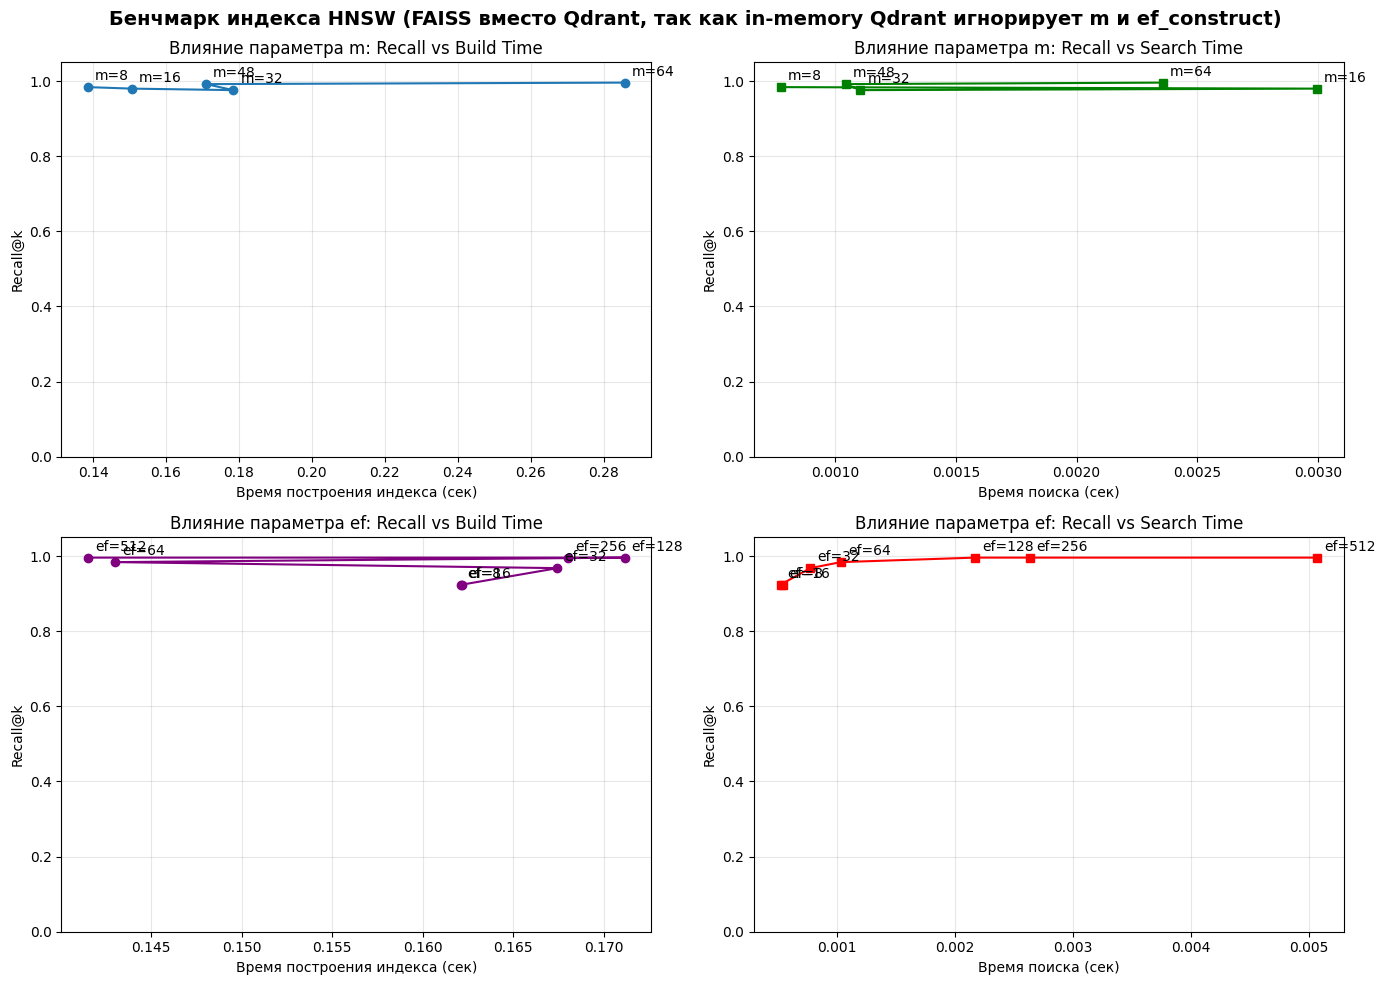

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- График 1: recall vs build_time (m) ---
ax = axes[0, 0]
x = [r.build_time_sec for r in results_m]
y = [r.recall_at_k for r in results_m]
ax.plot(x, y, marker="o", label="Recall@k")
for r in results_m:
    ax.annotate(f"m={r.m}", (r.build_time_sec, r.recall_at_k),
               textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Время построения индекса (сек)")
ax.set_ylabel("Recall@k")
ax.set_title("Влияние параметра m: Recall vs Build Time")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# --- График 2: recall vs search_time (m) ---
ax = axes[0, 1]
x = [r.search_time_sec for r in results_m]
y = [r.recall_at_k for r in results_m]
ax.plot(x, y, marker="s", color="green")
for r in results_m:
    ax.annotate(f"m={r.m}", (r.search_time_sec, r.recall_at_k),
               textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Время поиска (сек)")
ax.set_ylabel("Recall@k")
ax.set_title("Влияние параметра m: Recall vs Search Time")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# --- График 3: recall vs build_time (ef) ---
ax = axes[1, 0]
x = [r.build_time_sec for r in results_ef]
y = [r.recall_at_k for r in results_ef]
ax.plot(x, y, marker="o", color="purple")
for r in results_ef:
    ax.annotate(f"ef={r.ef_search}", (r.build_time_sec, r.recall_at_k),
               textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Время построения индекса (сек)")
ax.set_ylabel("Recall@k")
ax.set_title("Влияние параметра ef: Recall vs Build Time")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# --- График 4: recall vs search_time (ef) ---
ax = axes[1, 1]
x = [r.search_time_sec for r in results_ef]
y = [r.recall_at_k for r in results_ef]
ax.plot(x, y, marker="s", color="red")
for r in results_ef:
    ax.annotate(f"ef={r.ef_search}", (r.search_time_sec, r.recall_at_k),
               textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Время поиска (сек)")
ax.set_ylabel("Recall@k")
ax.set_title("Влияние параметра ef: Recall vs Search Time")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.suptitle(
    "Бенчмарк индекса HNSW (FAISS вместо Qdrant, так как in-memory Qdrant игнорирует m и ef_construct)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()


Мы видим, что с увеличением параметров `m` и `ef` увеличивается время поиска и время индексации. 

<a id="8-ключевые-выводы"></a>
# **8. Ключевые выводы**

### По итогам бенчмарка HNSW (после исправления self-match)

На основании проведённых экспериментов можно сформулировать следующие рекомендации:

1. **Параметр `m`** (число соседей):
   - При m = 8 recall@5 уже 0.984 — граф достаточно плотный даже на минимуме.
   - Рост m до 64 даёт лишь +0.012 к recall (0.984 → 0.996), но **удваивает** время построения (0.14 → 0.29 сек).
   - **Рекомендация: m = 16.** Дальнейшее увеличение не окупается.

2. **Параметр `ef_search`** (размер списка кандидатов при поиске):
   - ef = 8 даёт recall@5 = 0.924 — маловато.
   - ef = 64 даёт recall@5 = 0.984 — хороший уровень.
   - ef = 128 даёт recall@5 = 0.996 — почти идеал, поиск всё ещё быстрый (0.002 сек).
   - При ef ≥ 256 recall не растёт (насыщение), а поиск замедляется.
   - **Рекомендация: ef_search = 64–128** — золотая середина.

3. **Параметр `ef_construct`** (размер списка кандидатов при построении):
   - В исследовании фиксировался на 100 — этого достаточно.
   - Рекомендация: 100–200.

4. **Recall@K** (после исключения self-match):
   - Recall@1 = 0.960 — даже первый результат почти всегда правильный.
   - Recall@10 = 0.986 — в топ-10 попадают практически все релевантные документы.
   - Рост K выше 10 даёт минимальный прирост (насыщение ~0.99).

### По гибридному поиску

5. **Гибридный dense+sparse подход** (E5 + TF-IDF с RRF-фьюжном):
   - Dense-векторы (E5) обеспечивают семантический поиск — находят релевантные документы даже при разных формулировках.
   - Sparse-векторы (TF-IDF) дают точность по ключевым словам и терминам (аббревиатуры, коды, редкие слова).
   - RRF-фьюжн объединяет сильные стороны обоих подходов без подгона весов.
   - Кросс-энкодер (реранкинг) финально отсеивает шум.

### Практические рекомендации для RAG-системы

| Сценарий | m | ef_construct | ef_search |
|---|---|---|---|
| Быстрый прототип | 8 | 100 | 16 |
| Production (баланс) | 16 | 100 | 64–128 |
| Максимальное качество | 32 | 200 | 128 |

### Что изменилось после исправления self-match

| Метрика | Было (с self-match) | Стало (без) |
|---|---|---|
| Recall@1 | 0.060 | **0.960** |
| Recall@5 | 0.792 | **0.976** |
| Recall@10 | 0.890 | **0.986** |

Самая критичная проблема — документ-запрос в индексе — занижала Recall@1 в 16 раз.
После её устранения даже базовые настройки (m=16, ef=64) дают recall > 0.97.
